### Revised Statement
The overall goal of this project is to use a supervised ML-based spatial disaggregation that uses NASA's Soil Moisture Active Passive (SMAP) soil moisture as the coarse-scale reference and high-resolution radar, vegetation, and terrain variables to redistribute soil moisture within each SMAP footprint, with validation against in-situ measurements. The project will focus on the Little Washita/Fort Cobb SMAP Cal/Val region in Oklahoma. The first model will use Lasso regression as an interpretable baseline, and the second will use Random Forest regression to capture nonlinear relationships. Model predictions will be evaluated against available in-situ soil moisture observations and compared against a simple coarse-resolution SMAP baseline. For computational practicality, We will use SMAP L3 Enhanced 9 km soil moisture from Google Earth Engine (GEE) as the coarse passive microwave reference. The same framework can later be adapted to the classic 36 km SMAP L3 product.

### Region of Interest (ROI)
The ROI selected for this project is the southwestern Oklahoma SMAP calibration/validation region near Little Washita and Fort Cobb. NASA lists Little Washita, Oklahoma, and Fort Cobb, Oklahoma, as SMAP Cal/Val partner sites, with Little Washita (at approximately 34.97° N, -97.97° W) and Fort Cobb (at approximately 35.36° N, -98.55° W). This region was selected because it provides a manageable testbed for SMAP soil moisture downscaling, includes agricultural and grassland surfaces, and is more practical for a capstone workflow. More specifically, \
1- It is already an official SMAP validation region. \
2- It has meaningful soil moisture variability. Oklahoma has wet/dry transitions, agricultural land, grassland, and moderate terrain variability. That gives the ML model something real to learn. \
3- It is computationally manageable.

### Time Window
We use April 1 to September 30, 2024. This will provide enough soil moisture variation while avoiding winter freeze/thaw issues. Additionally, the current GEE SMAP L3 Enhanced collection is available for recent years and includes daily 9 km soil moisture data.

### Datasets
##### 1- NASA SMAP Level 3 Soil Moisture
The SMAP mission provides satellite-based estimates of near-surface soil moisture using an L-band microwave radiometer. In this project, SMAP will serve as the coarse-resolution reference soil moisture product that the ML model attempts to spatially downscale. The GEE collection NASA/SMAP/SPL3SMP_E/006 provides SMAP Level 3 Enhanced daily global soil moisture data at approximately 9 km spatial resolution, including bands for soil moisture, brightness temperature, vegetation water content, and quality information. SMAP is especially useful for this project because passive microwave observations are physically sensitive to soil dielectric properties and provide frequent, spatially continuous soil moisture estimates over large areas. However, the main limitation is that SMAP observations are too coarse for many local applications, such as field-scale irrigation, localized flood assessment, or high-resolution mobility analysis. Therefore, SMAP will be used as the coarse baseline product to be redistributed into a finer spatial grid using higher-resolution proxy variables.

##### 2- Sentinel-1 C-band SAR Backscatter
Sentinel-1 provides C-band Synthetic Aperture Radar (SAR) observations that are useful for mapping surface conditions at much finer spatial resolution than passive microwave soil moisture products. The GEE collection COPERNICUS/S1_GRD contains Sentinel-1 Ground Range Detected scenes that have been processed into calibrated, ortho-corrected radar backscatter values. The collection includes polarization bands such as VV and VH, as well as an incidence-angle band. In this project, Sentinel-1 VV and VH backscatter will be used as high-resolution radar proxy variables because radar backscatter is influenced by surface roughness, vegetation structure, and soil dielectric properties, all of which are related to spatial soil moisture variability. The VV/VH relationship may also provide useful information about vegetation and surface scattering mechanisms. A key limitation is that C-band radar backscatter is not controlled by soil moisture alone; it is also affected by vegetation, surface roughness, incidence angle, and terrain effects. For this reason, Sentinel-1 will be combined with NDVI and topographic variables rather than used by itself. Sentinel-1 data is also available at roughly 10 m, but predicting soil moisture at 10 m or even 30 m is too ambitious for this capstone project. A 1 km resolution is fine enough to show downscaling, but not so fine that the data volume becomes unmanageable.

##### 3- SRTM Digital Elevation Model
The Shuttle Radar Topography Mission (SRTM) Digital Elevation Model provides near-global elevation data at approximately 30 m spatial resolution. In GEE, the dataset USGS/SRTMGL1_003 contains the SRTM V3 product, also known as SRTM Plus, with an elevation band measured in meters. In this project, SRTM will be used to derive topographic predictors such as elevation, slope, and aspect. These variables are important because topography influences the spatial redistribution of water across the landscape. Lower-elevation areas and valleys may retain more moisture, while steep slopes may experience faster drainage. Aspect can also affect incoming solar radiation and drying rates. Although SRTM does not measure soil moisture directly, it provides physically meaningful terrain constraints that can help the model learn where wetter or drier areas are more likely to occur within a coarse SMAP footprint.

##### 4- MODIS NDVI
The Moderate Resolution Imaging Spectroradiometer (MODIS) vegetation index product MODIS/061/MOD13Q1 provides global vegetation indices, including the Normalized Difference Vegetation Index (NDVI), at 250 m spatial resolution and 16-day temporal intervals. NDVI is useful in this project because vegetation affects both soil moisture dynamics and radar backscatter. Areas with denser vegetation may retain more moisture through shading and reduced evaporation, but vegetation can also attenuate or scatter radar signals before they interact with the soil surface. Including NDVI helps the model account for vegetation-related differences in the radar-soil moisture relationship. MODIS NDVI is a practical first choice for the initial workflow because it is temporally consistent, already composited, and less cumbersome than building a cloud-free Landsat NDVI workflow from individual scenes. Its main limitation is that 250 m resolution is coarser than Sentinel-1 or Landsat, but it is still much finer than SMAP and suitable for a first 1 km downscaling experiment.

##### 5- Landsat-Derived NDVI
Landsat surface reflectance data can also be used to calculate NDVI at approximately 30 m spatial resolution. In GEE, Landsat Collection 2 Level 2 products provide atmospherically corrected surface reflectance from sensors such as Landsat 8 OLI/TIRS, including visible, near-infrared, and shortwave-infrared bands. NDVI can be calculated from the red and near-infrared bands and used as a higher-resolution vegetation proxy than MODIS NDVI. Landsat-derived NDVI may be useful if the project later requires finer spatial detail, especially for agricultural or heterogeneous landscapes. However, Landsat has a 16-day revisit cycle and optical observations are affected by clouds, cloud shadows, and atmospheric conditions. For this initial report, MODIS NDVI is likely easier to use; Landsat NDVI can be added later if higher spatial detail becomes necessary.

##### 6- International Soil Moisture Network
The International Soil Moisture Network (ISMN) is a global data hosting facility that provides harmonized and quality-controlled in-situ soil moisture measurements from ground monitoring networks. In this project, ISMN data will be used as independent validation data rather than as the main training target. This is important because the ML models will be trained to downscale SMAP soil moisture, while ISMN probe measurements provide an external reference for evaluating whether the downscaled predictions are physically meaningful at specific locations. A key limitation is scale mismatch: ISMN sensors measure soil moisture at a point and at specific depths, while satellite pixels represent spatial averages over much larger areas. Therefore, ISMN should be treated as high-quality validation data, but not as a perfect representation of every 1 km pixel. Moreover, ISMN had a major 2025 update for SCAN and SNOTEL networks, which is useful for U.S.-based work.

### Initial Multi-Sensor Map
An initial multi-sensor map is created in GEE for the selected southwestern Oklahoma ROI, defined by longitude -99.0 to -97.7 and latitude 34.5 to 35.8. The purpose of this map is to visually confirm that the main datasets required for the soil moisture downscaling workflow are available and spatially overlapping within the study area. The map includes the ROI boundary, mean SMAP soil moisture for April–September 2024, Sentinel-1 VV/VH radar backscatter composites, MODIS NDVI, and SRTM-derived elevation and slope layers. This visualization confirms that the selected ROI is suitable for building a preliminary multi-sensor raster stack before exporting the data into a tabular machine-learning format. The figure below shows an initial Google Earth Engine visualization of the southwestern Oklahoma ROI. The map confirms spatial overlap among SMAP soil moisture and SRTM slope variables for the April–September 2024 study. Other layers are not shown for brevity.

<img src="image/Fig1.png" width="800">

### ISMN Station Availability
The next step was to check the availability of in-situ soil moisture observations from the International Soil Moisture Network (ISMN) for the selected southwestern Oklahoma ROI. ISMN was selected as the validation source because it provides harmonized in-situ soil moisture observations from ground-based monitoring networks and is commonly used for validation of satellite soil moisture products. The search focused on stations located inside or near the ROI bounded by longitude -99.0 to -97.7 and latitude 34.5 to 35.8, with a slightly larger surrounding area also inspected to identify nearby validation stations. The target validation period was April 1, 2024 through September 30, 2024, matching the initial satellite compositing period used in Google Earth Engine. The preferred validation measurements are shallow soil moisture observations, ideally from 0–5 cm or 0–10 cm depth, because these are most comparable to the near-surface soil moisture represented by SMAP. Station metadata, including network name, station name, coordinates, available depths, date coverage, and quality-flag availability, will be recorded before downloading and processing the time series.
For the capstone workflow, ISMN observations will be used as independent validation data rather than as the primary training target. The machine-learning model will first be trained using SMAP soil moisture as the coarse reference variable and Sentinel-1, NDVI, and topographic predictors as explanatory variables. The downscaled predictions will then be evaluated at station locations by comparing the predicted soil moisture values against ISMN probe measurements. In investigating ISMN, soil moisture data from one station in the ROI met our criteria above. Details are summarized below.
| Station | Network | Lat	| Lon | Depth | Date Coverage | Usable |
| --- | --- | --- | --- | --- | ---| ---| 
Fort Reno #1 | USDA Soil Climate Analysis Network (SCAN) | 35.5500 | -98.0167 |	5 cm | 1998-11-17 16:00:00 to 2025-03-22 11:00:00 | Yes |

The figure below shows the identified ISMN station (marked in red) within the project's ROI.

<img src="image/Fig2.png" width="800">

The identified ISMN station will limit in-situ validation availability within the selected ROI. Because the initial raster-stack workflow uses monthly composites, this would provide only six station-month observations for ground validation. Therefore, the 2024-only validation will be treated as a preliminary feasibility check rather than a robust statistical validation. To strengthen the final project, the validation dataset may be expanded by including additional years, using a finer temporal compositing interval, or expanding the ROI/search buffer to include more nearby stations.

### Google Earth Engine (GEE) Dataset Setup
The first data preparation step is to set up the required datasets in GEE for the selected region of interest. The ROI was defined as a rectangular area bounded by longitude -99.0 to -97.7 and latitude 34.5 to 35.8. The initial analysis period was set to April 1, 2024 through September 30, 2024 in order to focus on the growing season and avoid winter freeze/thaw complications.

After confirming dataset availability, monthly raster stacks are created in GEE. Rather than building daily stacks, monthly composites are used for the initial workflow to simplify temporal alignment among datasets with different revisit intervals. SMAP provides frequent soil moisture observations, Sentinel-1 does not acquire imagery every day over the same location, and MODIS NDVI is distributed as a 16-day vegetation index product. Monthly compositing therefore provides a practical first approximation for combining the datasets into a common ML format.

The GEE workflow successfully generated six monthly fine-resolution raster stacks and six SMAP-scale (i.e., 9 km) training stacks for April–September 2024. The fine-resolution stacks contain mean SMAP soil moisture, median Sentinel-1 VV and VH backscatter, median Sentinel-1 incidence angle, median MODIS NDVI, and static SRTM-derived terrain variables including elevation, slope, and aspect, and engineered predictors such as VV–VH difference and aspect sine/cosine components. A valid SMAP mask was applied so that only pixels with available SMAP soil moisture values are retained. For model training, the high-resolution predictors were aggregated to the SMAP grid so that each training row represents one SMAP-scale pixel-month observation. The resulting SMAP-scale training sample contained 1,543 observations, confirming that the dataset is large enough for initial exploratory analysis and preliminary regression modeling. The 9km stacked raster, which will be used for training will be exported to a tabular dataset, where each row represents a pixel-month observation and each band becomes a ML variable.

### Initial Data Analysis and Modeling
We can now proceed to data cleaning, exploratory data analysis, visualizations, building models (Lasso and Random Forest), and evaluation metrics.

##### Import modules

In [1]:
# Basic data handling
import pandas as pd
import numpy as np

# Plotting
import matplotlib.pyplot as plt

# Machine learning models
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Lasso
from sklearn.ensemble import RandomForestRegressor

# Preprocessing and pipelines
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Evaluation metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

##### Load the Exported GEE CSV File (SMAP Scale)

In [4]:
# ---------------------------------------------------------
# Load SMAP-scale training table exported from GEE
# ---------------------------------------------------------

file_path = "data/oklahoma_smap_scale_training_Apr_Sep_2024.csv"

df = pd.read_csv(file_path)

# Show the first few rows
df.head()

,system:index,lat,lon,mean_angle,mean_aspect_cos,mean_aspect_sin,mean_elevation,mean_ndvi,mean_slope,mean_vh,mean_vv,mean_vv_minus_vh,month,smap_sm,.geo
0,0_0,35.724502,-99.00,40.309376,-0.609858,-0.187981,553.531943,0.558202,0.459415,-20.259534,-14.773767,5.485768,4,0.134373,"{""type"":""MultiPoint"",""coordinates"":[]}"
1,0_1,35.724502,-98.92,40.617447,-0.433592,0.226520,553.307459,0.575586,0.390987,-20.057032,-14.521686,5.535347,4,0.131229,"{""type"":""MultiPoint"",""coordinates"":[]}"
2,0_2,35.724502,-98.84,41.030060,-0.394802,0.153716,540.197593,0.556254,0.433073,-20.231718,-14.270491,5.961227,4,0.128953,"{""type"":""MultiPoint"",""coordinates"":[]}"
3,0_3,35.724502,-98.76,34.027702,-0.473666,0.076290,531.580114,0.607574,0.413125,-20.366988,-14.460086,5.906902,4,0.133093,"{""type"":""MultiPoint"",""coordinates"":[]}"
4,0_4,35.724502,-98.68,30.500061,0.221223,0.275984,517.653861,0.583666,0.581825,-20.503833,-14.074337,6.429496,4,0.134904,"{""type"":""MultiPoint"",""coordinates"":[]}"


##### Basic Dataset Inspection

In [5]:

# Dataset size: rows and columns
print("Dataset shape:", df.shape)

# Column names
print("\nColumn names:")
print(df.columns.tolist())

# Basic information about data types and missing values
print("\nDataset info:")
df.info()

Dataset shape: (1543, 15)

Column names:
['system:index', 'lat', 'lon', 'mean_angle', 'mean_aspect_cos', 'mean_aspect_sin', 'mean_elevation', 'mean_ndvi', 'mean_slope', 'mean_vh', 'mean_vv', 'mean_vv_minus_vh', 'month', 'smap_sm', '.geo']

Dataset info:
<class 'pandas.DataFrame'>
RangeIndex: 1543 entries, 0 to 1542
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   system:index      1543 non-null   str    
 1   lat               1543 non-null   float64
 2   lon               1543 non-null   float64
 3   mean_angle        1543 non-null   float64
 4   mean_aspect_cos   1543 non-null   float64
 5   mean_aspect_sin   1543 non-null   float64
 6   mean_elevation    1543 non-null   float64
 7   mean_ndvi         1543 non-null   float64
 8   mean_slope        1543 non-null   float64
 9   mean_vh           1543 non-null   float64
 10  mean_vv           1543 non-null   float64
 11  mean_vv_minus_vh  1543 non-null   

##### Summary Statistics

In [6]:
# Summary statistics for numeric columns
df.describe()

,lat,lon,mean_angle,mean_aspect_cos,mean_aspect_sin,mean_elevation,mean_ndvi,mean_slope,mean_vh,mean_vv,mean_vv_minus_vh,month,smap_sm
count,1543.000000,1543.000000,1543.000000,1543.000000,1543.000000,1543.000000,1543.000000,1543.000000,1543.000000,1543.000000,1543.000000,1543.000000,1543.000000
mean,35.128416,-98.334076,39.333990,-0.104058,0.110592,424.861678,0.521890,0.526250,-19.245742,-12.552764,6.692977,6.413480,0.138457
std,0.368886,0.386146,4.758052,0.339862,0.298769,54.434488,0.092542,0.227812,1.244747,1.083901,0.507405,1.717424,0.042540
min,34.524502,-99.000000,30.467625,-0.808295,-0.723448,329.120384,0.263679,0.205231,-24.473615,-15.856819,5.333354,4.000000,0.072506
25%,34.844502,-98.680000,34.604769,-0.359761,-0.095236,381.792073,0.457928,0.402279,-20.044331,-13.258198,6.335257,5.000000,0.104112
50%,35.164502,-98.360000,40.624466,-0.141551,0.148572,417.143190,0.529166,0.477698,-19.094932,-12.423546,6.621525,6.000000,0.128297
75%,35.484502,-98.040000,43.175405,0.153410,0.338798,464.429906,0.594121,0.587434,-18.341751,-11.842837,6.998084,8.000000,0.170034
max,35.724502,-97.720000,46.229935,0.698848,0.831842,567.566476,0.742504,2.011825,-15.296550,-8.683659,9.682197,9.000000,0.251999


##### Check Missing Values and Duplicates

In [7]:
# Count missing values in each column
missing_values = df.isna().sum()

print("Missing values by column:")
print(missing_values)

# Count duplicate rows
duplicate_count = df.duplicated().sum()

print("\nNumber of duplicate rows:", duplicate_count)

Missing values by column:
system:index        0
lat                 0
lon                 0
mean_angle          0
mean_aspect_cos     0
mean_aspect_sin     0
mean_elevation      0
mean_ndvi           0
mean_slope          0
mean_vh             0
mean_vv             0
mean_vv_minus_vh    0
month               0
smap_sm             0
.geo                0
dtype: int64

Number of duplicate rows: 0


##### Clean the Dataset

In [8]:
# ---------------------------------------------------------
# Data cleaning
# ---------------------------------------------------------

# Make a copy before cleaning
df_clean = df.copy()

# Remove duplicate rows
df_clean = df_clean.drop_duplicates()

# Remove rows with missing values
df_clean = df_clean.dropna()

# Keep physically reasonable values
# SMAP soil moisture is volumetric water content, usually between 0 and about 0.6 m³/m³.
# NDVI should generally be between -0.2 and 1.0 for this type of land analysis.
df_clean = df_clean[
    (df_clean["smap_sm"] >= 0) &
    (df_clean["smap_sm"] <= 0.6) &
    (df_clean["mean_ndvi"] >= -0.2) &
    (df_clean["mean_ndvi"] <= 1.0)
]

print("Original shape:", df.shape)
print("Cleaned shape:", df_clean.shape)

df_clean.head()

Original shape: (1543, 15)
Cleaned shape: (1543, 15)


,system:index,lat,lon,mean_angle,mean_aspect_cos,mean_aspect_sin,mean_elevation,mean_ndvi,mean_slope,mean_vh,mean_vv,mean_vv_minus_vh,month,smap_sm,.geo
0,0_0,35.724502,-99.00,40.309376,-0.609858,-0.187981,553.531943,0.558202,0.459415,-20.259534,-14.773767,5.485768,4,0.134373,"{""type"":""MultiPoint"",""coordinates"":[]}"
1,0_1,35.724502,-98.92,40.617447,-0.433592,0.226520,553.307459,0.575586,0.390987,-20.057032,-14.521686,5.535347,4,0.131229,"{""type"":""MultiPoint"",""coordinates"":[]}"
2,0_2,35.724502,-98.84,41.030060,-0.394802,0.153716,540.197593,0.556254,0.433073,-20.231718,-14.270491,5.961227,4,0.128953,"{""type"":""MultiPoint"",""coordinates"":[]}"
3,0_3,35.724502,-98.76,34.027702,-0.473666,0.076290,531.580114,0.607574,0.413125,-20.366988,-14.460086,5.906902,4,0.133093,"{""type"":""MultiPoint"",""coordinates"":[]}"
4,0_4,35.724502,-98.68,30.500061,0.221223,0.275984,517.653861,0.583666,0.581825,-20.503833,-14.074337,6.429496,4,0.134904,"{""type"":""MultiPoint"",""coordinates"":[]}"


##### Confirm the Final Columns

In [10]:
# Check all column names
print(df_clean.columns.tolist())

# Drop the .geo column if it exists
if ".geo" in df_clean.columns:
    df_clean = df_clean.drop(columns=[".geo"])

# Confirm final columns
print("\nFinal columns after removing .geo if present:")
print(df_clean.columns.tolist())

['system:index', 'lat', 'lon', 'mean_angle', 'mean_aspect_cos', 'mean_aspect_sin', 'mean_elevation', 'mean_ndvi', 'mean_slope', 'mean_vh', 'mean_vv', 'mean_vv_minus_vh', 'month', 'smap_sm', '.geo']

Final columns after removing .geo if present:
['system:index', 'lat', 'lon', 'mean_angle', 'mean_aspect_cos', 'mean_aspect_sin', 'mean_elevation', 'mean_ndvi', 'mean_slope', 'mean_vh', 'mean_vv', 'mean_vv_minus_vh', 'month', 'smap_sm']


##### SMAP Soil Moisture Distribution
The histogram shows the distribution of the smap_sm target variable in the cleaned dataset. Each value represents monthly mean SMAP soil moisture for one SMAP-scale pixel-month observation. This plot is used to check the range and frequency of soil moisture values, identify possible extreme values, and confirm that the target variable contains enough variation for preliminary regression modeling.

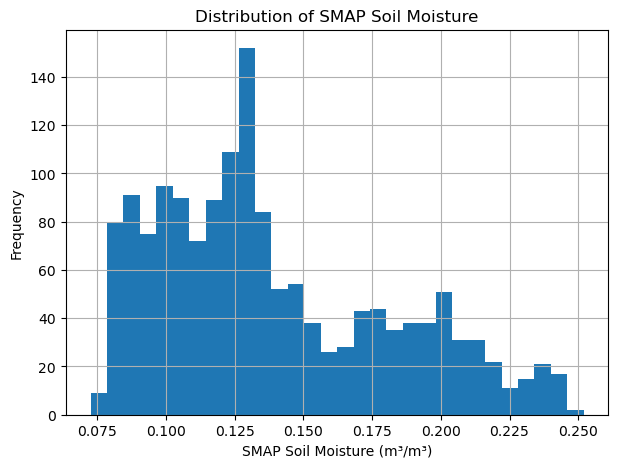

In [12]:
plt.figure(figsize=(7, 5))
plt.hist(df_clean["smap_sm"], bins=30)
plt.xlabel("SMAP Soil Moisture (m³/m³)")
plt.ylabel("Frequency")
plt.title("Distribution of SMAP Soil Moisture")
plt.grid(True)
plt.show()

##### Monthly Average SMAP Soil Moisture
The plot below shows ROI-level monthly averages. We should note that the exported SMAP-scale training table is monthly composited but preserves spatial variation. That is, each row represents one SMAP-scale pixel-month observation, rather than one average value for the entire ROI.

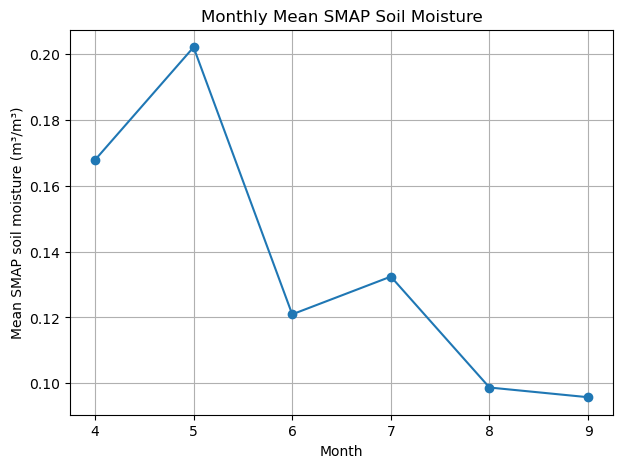

month
4    0.167802
5    0.202055
6    0.120956
7    0.132411
8    0.098736
9    0.095788
Name: smap_sm, dtype: float64

In [13]:
monthly_mean = df_clean.groupby("month")["smap_sm"].mean()

plt.figure(figsize=(7, 5))
monthly_mean.plot(marker="o")
plt.xlabel("Month")
plt.ylabel("Mean SMAP soil moisture (m³/m³)")
plt.title("Monthly Mean SMAP Soil Moisture")
plt.grid(True)
plt.show()

monthly_mean

##### Spatial Distribution of SMAP Soil Moisture Samples
The spatial scatter plots below show the locations of the SMAP-scale training samples within the ROI. Each point represents one valid SMAP-scale pixel for a selected month, and the color indicates monthly mean SMAP soil moisture in m³/m³. This plot was used to visually inspect the spatial coverage of the exported training samples and to confirm that soil moisture varies across the study area. The plot is an exploratory visualization of the training data, not a final downscaled prediction map.


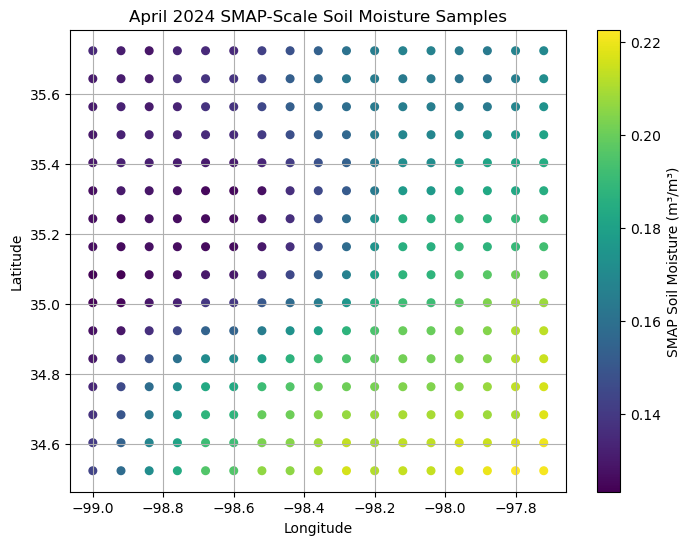

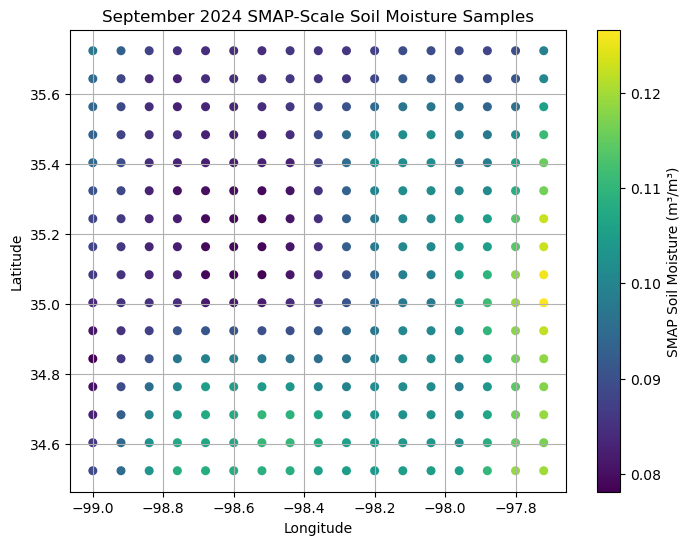

In [16]:
april_df = df_clean[df_clean["month"] == 4]

plt.figure(figsize=(8, 6))
plt.scatter(
    april_df["lon"],
    april_df["lat"],
    c=april_df["smap_sm"],
    s=30
)

plt.colorbar(label="SMAP Soil Moisture (m³/m³)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("April 2024 SMAP-Scale Soil Moisture Samples")
plt.grid(True)
plt.show()

sept_df = df_clean[df_clean["month"] == 9]

plt.figure(figsize=(8, 6))
plt.scatter(
    sept_df["lon"],
    sept_df["lat"],
    c=sept_df["smap_sm"],
    s=30
)

plt.colorbar(label="SMAP Soil Moisture (m³/m³)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("September 2024 SMAP-Scale Soil Moisture Samples")
plt.grid(True)
plt.show()

##### Correlation Matrix
The correlation matrix is used as an exploratory tool to examine linear relationships among SMAP soil moisture and the aggregated predictor variables. The analysis used the cleaned SMAP-scale training samples, where each row represents one SMAP-scale pixel-month observation. These correlations help identify potential predictor relationships but do not establish causation or final model performance.

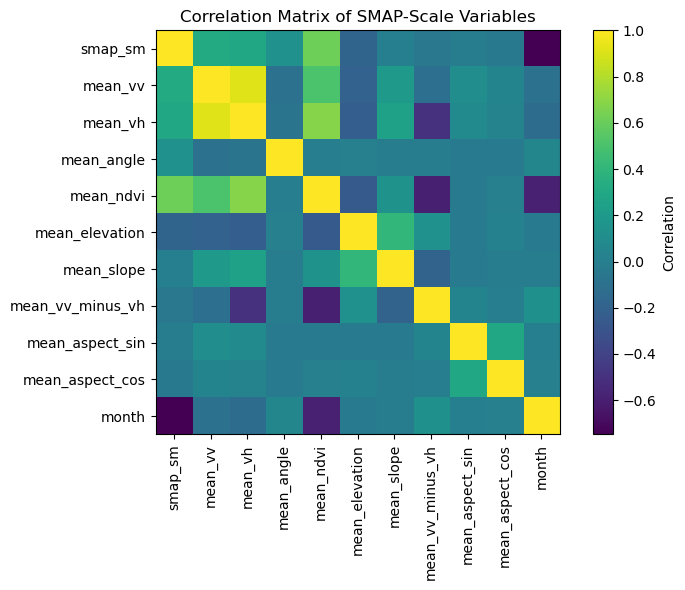

,smap_sm,mean_vv,mean_vh,mean_angle,mean_ndvi,mean_elevation,mean_slope,mean_vv_minus_vh,mean_aspect_sin,mean_aspect_cos,month
smap_sm,1.000000,0.318617,0.297794,0.138545,0.616977,-0.185853,0.007214,-0.049919,-0.004594,-0.039778,-0.747952
mean_vv,0.318617,1.000000,0.914175,-0.088222,0.507785,-0.198922,0.198083,-0.106453,0.108082,0.039737,-0.087591
mean_vh,0.297794,0.914175,1.000000,-0.072522,0.684691,-0.228854,0.249485,-0.500334,0.078268,0.034127,-0.128234
mean_angle,0.138545,-0.088222,-0.072522,1.000000,-0.001375,0.011541,-0.006831,-0.010549,-0.022487,-0.025544,0.054621
mean_ndvi,0.616977,0.507785,0.684691,-0.001375,1.000000,-0.253803,0.141709,-0.594946,-0.017606,0.015345,-0.590814
mean_elevation,-0.185853,-0.198922,-0.228854,0.011541,-0.253803,1.000000,0.409812,0.136486,-0.027107,0.018847,-0.037142
mean_slope,0.007214,0.198083,0.249485,-0.006831,0.141709,0.409812,1.000000,-0.188890,-0.037811,-0.012656,-0.010689
mean_vv_minus_vh,-0.049919,-0.106453,-0.500334,-0.010549,-0.594946,0.136486,-0.188890,1.000000,0.038877,0.001167,0.127469
mean_aspect_sin,-0.004594,0.108082,0.078268,-0.022487,-0.017606,-0.027107,-0.037811,0.038877,1.000000,0.301785,0.008510
mean_aspect_cos,-0.039778,0.039737,0.034127,-0.025544,0.015345,0.018847,-0.012656,0.001167,0.301785,1.000000,0.011519


In [37]:
corr_columns = [
    "smap_sm",
    "mean_vv",
    "mean_vh",
    "mean_angle",
    "mean_ndvi",
    "mean_elevation",
    "mean_slope",
    "mean_vv_minus_vh",
    "mean_aspect_sin",
    "mean_aspect_cos",
    "month"
]

corr = df_clean[corr_columns].corr()

plt.figure(figsize=(8, 6))
plt.imshow(corr)
plt.colorbar(label="Correlation")

plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=90
)

plt.yticks(
    range(len(corr.columns)),
    corr.columns
)

plt.title("Correlation Matrix of SMAP-Scale Variables")
plt.tight_layout()
plt.show()

corr

##### Define Predictors and Target

In [18]:
# ---------------------------------------------------------
# Define feature variables and target variable
# ---------------------------------------------------------

features = [
    "mean_vv",
    "mean_vh",
    "mean_angle",
    "mean_ndvi",
    "mean_elevation",
    "mean_slope",
    "mean_vv_minus_vh",
    "mean_aspect_sin",
    "mean_aspect_cos",
    "month"
]

target = "smap_sm"

X = df_clean[features]
y = df_clean[target]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

Feature matrix shape: (1543, 10)
Target shape: (1543,)


##### Temporal Train-Test Split
We use April–August for training and September for testing.

In [19]:
# ---------------------------------------------------------
# Temporal split
# Train: April through August
# Test: September
# ---------------------------------------------------------

train_df = df_clean[df_clean["month"] < 9]
test_df = df_clean[df_clean["month"] == 9]

X_train = train_df[features]
y_train = train_df[target]

X_test = test_df[features]
y_test = test_df[target]

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (1271, 10)
Testing data shape: (272, 10)


##### Define Evaluation Function

In [20]:
def evaluate_model(model_name, y_true, y_pred):
    """
    Evaluate regression model performance.
    Returns RMSE, MAE, and R².
    """
    
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    return {
        "Model": model_name,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2
    }

##### Baseline Model
A mean baseline model is included to provide a reference point for model performance. For each September test pixel, the baseline model predicts the same value: the average SMAP soil moisture calculated from all April–August training samples across all SMAP-scale pixel locations. Therefore, the baseline average is not calculated separately for each pixel. It is a global training-period mean over both space and time. This baseline model does not use Sentinel-1 backscatter, NDVI, terrain variables, month-specific spatial patterns, or location information. Therefore, Lasso Regression and Random Forest Regression should outperform this baseline to demonstrate that the predictor variables add useful information for estimating SMAP soil moisture.

In [21]:
# ---------------------------------------------------------
# Baseline model
# Predicts the mean soil moisture from the training set
# ---------------------------------------------------------

results = []

baseline = DummyRegressor(strategy="mean")

baseline.fit(X_train, y_train)

baseline_preds = baseline.predict(X_test)

baseline_results = evaluate_model(
    "Mean Baseline",
    y_test,
    baseline_preds
)

results.append(baseline_results)

baseline_results

{'Model': 'Mean Baseline',
 'RMSE': np.float64(0.053011476780423374),
 'MAE': 0.05180055020460093,
 'R2': -21.14169556119701}

##### Lasso Regression Model
A Lasso Regression model is trained as the preliminary linear modeling approach. Before fitting the model, the predictor variables were standardized using StandardScaler so that variables with different units, such as radar backscatter, NDVI, elevation, and slope, could be compared on a common scale. Lasso Regression was selected because it provides both prediction and feature-selection benefits through L1 regularization. In this analysis, the model was trained using April–August SMAP-scale samples and tested on September samples. The model used aggregated Sentinel-1, NDVI, terrain, aspect-derived variables, and month as predictors to estimate SMAP soil moisture. Its performance was evaluated using RMSE, MAE, and R².

In [22]:
# ---------------------------------------------------------
# Lasso Regression
# Linear model with L1 regularization
# ---------------------------------------------------------

lasso_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("lasso", Lasso(alpha=0.001, max_iter=10000))
])

lasso_pipe.fit(X_train, y_train)

lasso_preds = lasso_pipe.predict(X_test)

lasso_results = evaluate_model(
    "Lasso Regression",
    y_test,
    lasso_preds
)

results.append(lasso_results)

lasso_results

{'Model': 'Lasso Regression',
 'RMSE': np.float64(0.018114311743215192),
 'MAE': 0.015289635450861002,
 'R2': -1.5853226112681447}

##### Random Forest Regression Model
A Random Forest Regression model is trained as the preliminary nonlinear modeling approach. Unlike Lasso Regression, Random Forest can capture nonlinear relationships and interactions among predictors. This is useful for soil moisture downscaling because the relationship between SMAP soil moisture and proxy variables such as Sentinel-1 backscatter, NDVI, and terrain is unlikely to be purely linear. The model was trained on April–August SMAP-scale pixel-month samples and tested on September samples. The Random Forest included 100 decision trees, and the final prediction for each test sample was based on the average prediction across the trees. Model performance was evaluated using RMSE, MAE, and R².

In [23]:
# ---------------------------------------------------------
# Random Forest Regression
# Nonlinear ensemble model
# ---------------------------------------------------------

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    min_samples_leaf=5,
    n_jobs=-1
)

rf.fit(X_train, y_train)

rf_preds = rf.predict(X_test)

rf_results = evaluate_model(
    "Random Forest Regression",
    y_test,
    rf_preds
)

results.append(rf_results)

rf_results

{'Model': 'Random Forest Regression',
 'RMSE': np.float64(0.02196116237346109),
 'MAE': 0.019459879868288642,
 'R2': -2.7999835393044963}

##### Model Comparison Table
The model comparison table below summarizes the performance of the mean baseline, Lasso Regression, and Random Forest Regression models. The mean baseline provides a simple reference case by predicting the same average training-period soil moisture value for every September test pixel. The Lasso and Random Forest models are then compared against this baseline to determine whether the satellite and terrain predictor variables provide additional predictive value. RMSE and MAE measure prediction error, where lower values indicate better performance. R² measures the proportion of variation in September SMAP soil moisture explained by the model, where higher values indicate better performance.

In [24]:
# ---------------------------------------------------------
# Compare model performance
# ---------------------------------------------------------

results_df = pd.DataFrame(results)

results_df

,Model,RMSE,MAE,R2
0,Mean Baseline,0.053011,0.051801,-21.141696
1,Lasso Regression,0.018114,0.015290,-1.585323
2,Random Forest Regression,0.021961,0.019460,-2.799984


##### Predicted vs. Observed Plots
These plots are used to visually evaluate both models' performances on the September test data. Each point represents one SMAP-scale September test sample. The x-axis shows the observed SMAP soil moisture value, while the y-axis shows the prediction. The dashed line represents perfect agreement between observed and predicted values. Points close to the dashed line indicate better model performance, while points far from the line indicate larger prediction errors. This plot provides a visual complement to the quantitative RMSE, MAE, and R² results.

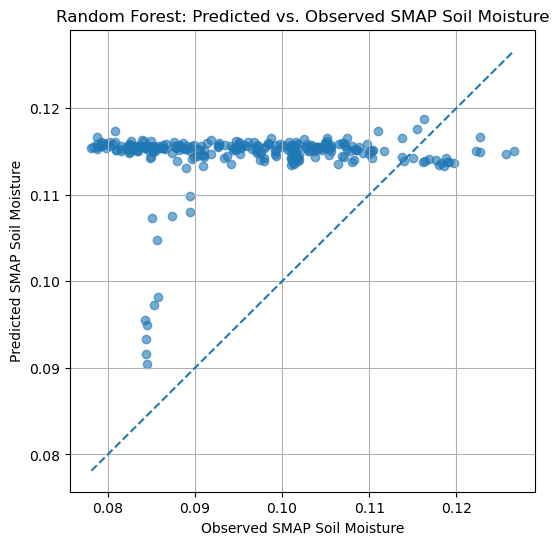

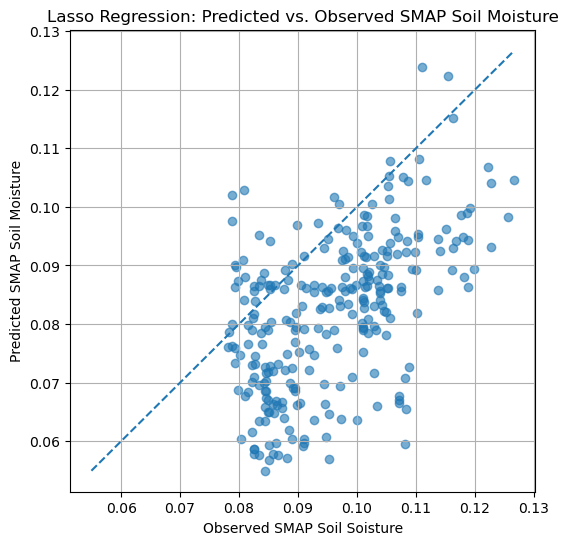

In [28]:
# ---------------------------------------------------------
# Predicted vs. observed plot for Random Forest
# ---------------------------------------------------------

plt.figure(figsize=(6, 6))

plt.scatter(
    y_test,
    rf_preds,
    alpha=0.6
)

plt.xlabel("Observed SMAP Soil Moisture")
plt.ylabel("Predicted SMAP Soil Moisture")
plt.title("Random Forest: Predicted vs. Observed SMAP Soil Moisture")
plt.grid(True)

# Add 1:1 reference line
min_val = min(y_test.min(), rf_preds.min())
max_val = max(y_test.max(), rf_preds.max())

plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

plt.show()

# ---------------------------------------------------------
# Predicted vs. observed plot for Lasso Regression
# ---------------------------------------------------------

plt.figure(figsize=(6, 6))

plt.scatter(
    y_test,
    lasso_preds,
    alpha=0.6
)

plt.xlabel("Observed SMAP Soil Soisture")
plt.ylabel("Predicted SMAP Soil Moisture")
plt.title("Lasso Regression: Predicted vs. Observed SMAP Soil Moisture")
plt.grid(True)

# Add 1:1 reference line
min_val = min(y_test.min(), lasso_preds.min())
max_val = max(y_test.max(), lasso_preds.max())

plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

plt.show()

##### Random Forest Feature Importance
Random Forest feature importance is used to examine which predictor variables contributed most to the nonlinear model. The feature-importance values indicate how strongly each variable helped reduce prediction error across the ensemble of decision trees. Higher values suggest that the model relied more heavily on that predictor when estimating SMAP soil moisture. This analysis helps interpret whether radar backscatter, vegetation, terrain, aspect-derived variables, or month were most influential in the preliminary model. However, feature importance should be interpreted as a model-based diagnostic rather than evidence of direct physical causation.

In [29]:
# ---------------------------------------------------------
# Random Forest feature importance
# ---------------------------------------------------------

importance_df = pd.DataFrame({
    "feature": features,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False)

importance_df

,feature,importance
9,month,0.724550
0,mean_vv,0.118718
4,mean_elevation,0.073101
2,mean_angle,0.025484
3,mean_ndvi,0.020032
5,mean_slope,0.012360
8,mean_aspect_cos,0.009360
1,mean_vh,0.006871
6,mean_vv_minus_vh,0.005970
7,mean_aspect_sin,0.003554


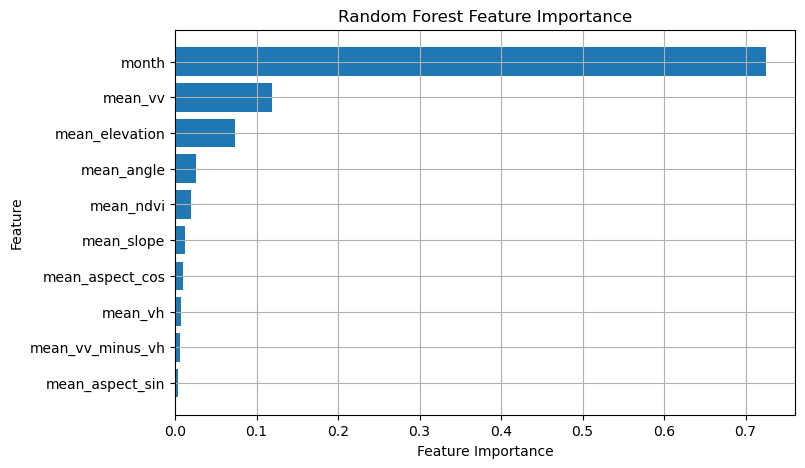

In [33]:
plt.figure(figsize=(8, 5))

plt.barh(
    importance_df["feature"],
    importance_df["importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")
plt.gca().invert_yaxis()
plt.grid(True)

plt.show()

##### Lasso Coefficients
Lasso coefficients are examined to interpret the preliminary linear relationship between each predictor and SMAP soil moisture. Because the predictors were standardized before model fitting, the coefficients are more comparable across variables with different units. Positive coefficients indicate that higher predictor values are associated with higher predicted SMAP soil moisture, while negative coefficients indicate that higher predictor values are associated with lower predicted soil moisture. Coefficients near zero suggest weak contribution in the linear model, and coefficients equal to zero indicate that Lasso effectively removed that predictor through regularization. This provides an interpretable comparison to the more flexible Random Forest model.

In [31]:
# ---------------------------------------------------------
# Lasso Regression coefficients
# ---------------------------------------------------------

lasso_model = lasso_pipe.named_steps["lasso"]

lasso_coef_df = pd.DataFrame({
    "feature": features,
    "coefficient": lasso_model.coef_
}).sort_values("coefficient", key=abs, ascending=False)

lasso_coef_df

,feature,coefficient
9,month,-0.022508
3,mean_ndvi,0.010854
6,mean_vv_minus_vh,0.008331
0,mean_vv,0.006590
2,mean_angle,0.006445
4,mean_elevation,-0.004938
8,mean_aspect_cos,-0.000419
1,mean_vh,0.000000
5,mean_slope,0.000000
7,mean_aspect_sin,-0.000000


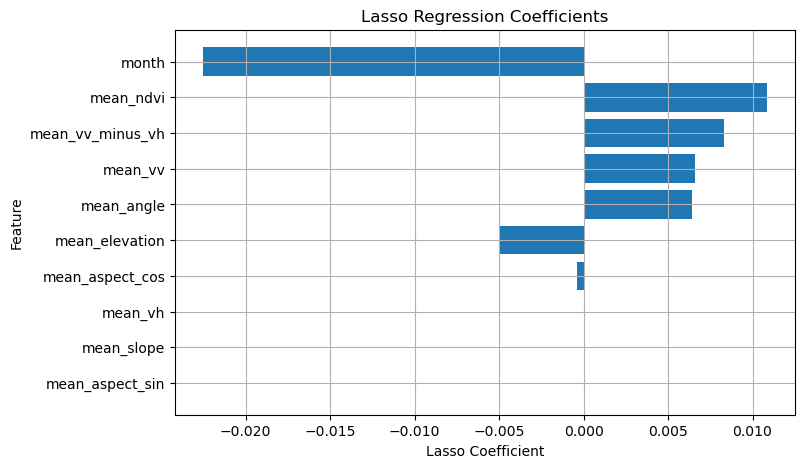

In [34]:
plt.figure(figsize=(8, 5))

plt.barh(
    lasso_coef_df["feature"],
    lasso_coef_df["coefficient"]
)

plt.xlabel("Lasso Coefficient")
plt.ylabel("Feature")
plt.title("Lasso Regression Coefficients")
plt.gca().invert_yaxis()
plt.grid(True)

plt.show()

##### Add predictions to the Test DataFrame
The predictions from the baseline, Lasso Regression, and Random Forest Regression models are added back to the September test dataframe. This allows direct row-by-row comparison between the observed SMAP soil moisture value and each model’s predicted value for the same SMAP-scale test sample. The resulting dataframe is useful for error analysis, comparison of model behavior, and later mapping or spatial inspection of prediction errors. It also preserves the original test-sample information, including location, predictor variables, observed SMAP soil moisture, and model predictions.

In [35]:
# ---------------------------------------------------------
# Add model predictions to the September test dataframe
# ---------------------------------------------------------

test_results = test_df.copy()

test_results["baseline_pred"] = baseline_preds
test_results["lasso_pred"] = lasso_preds
test_results["rf_pred"] = rf_preds

test_results.head()

,system:index,lat,lon,mean_angle,mean_aspect_cos,mean_aspect_sin,mean_elevation,mean_ndvi,mean_slope,mean_vh,mean_vv,mean_vv_minus_vh,month,smap_sm,baseline_pred,lasso_pred,rf_pred
1271,5_0,35.724502,-99.00,40.329063,-0.609858,-0.187981,553.531943,0.358263,0.459415,-21.129284,-13.838150,7.291135,9,0.097249,0.147589,0.063798,0.115632
1272,5_1,35.724502,-98.92,40.637030,-0.433592,0.226520,553.307459,0.340228,0.390987,-21.019706,-13.674241,7.345465,9,0.092736,0.147589,0.063557,0.115688
1273,5_2,35.724502,-98.84,41.049557,-0.394802,0.153716,540.197593,0.347290,0.433073,-21.027361,-13.774211,7.253150,9,0.087642,0.147589,0.063940,0.116132
1274,5_3,35.724502,-98.76,37.120960,-0.473666,0.076290,531.580114,0.336731,0.413125,-21.002158,-13.189200,7.812958,9,0.084945,0.147589,0.071781,0.116164
1275,5_4,35.724502,-98.68,30.497356,0.221223,0.275984,517.653861,0.389382,0.581825,-20.706441,-13.269670,7.436771,9,0.084422,0.147589,0.063367,0.091615


##### Save Results
The main outputs from the preliminary modeling workflow are saved as CSV files for documentation and reuse in the final project. These files provide a foundation for later model refinement, spatial error analysis, and comparison with external validation data such as ISMN station observations.

In [36]:
# ---------------------------------------------------------
# Save outputs for report and final project
# ---------------------------------------------------------

# Save model comparison table
results_df.to_csv("initial_model_results.csv", index=False)

# Save Random Forest feature importance
importance_df.to_csv("random_forest_feature_importance.csv", index=False)

# Save Lasso coefficients
lasso_coef_df.to_csv("lasso_coefficients.csv", index=False)

# Save September test predictions
test_results.to_csv("september_test_predictions.csv", index=False)

### Summary amd Next Steps
Preliminary modeling was conducted using the SMAP-scale training table exported from Google Earth Engine. The target variable was monthly SMAP soil moisture, and the predictors included aggregated Sentinel-1 VV and VH backscatter, incidence angle, MODIS NDVI, elevation, slope, VV–VH difference, aspect sine and cosine components, and month. A temporal train-test split was used, with April–August samples used for training and September samples used for testing. Three models were compared: a mean baseline model, Lasso Regression, and Random Forest Regression. The baseline model predicted the global (i.e., ROI level) April–August mean SMAP soil moisture for every September test pixel and served as a reference point. Lasso Regression provided an interpretable linear model with regularization, while Random Forest Regression provided a nonlinear ensemble model capable of capturing more complex relationships. Model performance was evaluated using RMSE, MAE, and R². Additional interpretation was performed using Random Forest feature importance and Lasso coefficients. Finally, the model metrics, feature-importance values, coefficients, and September test predictions were saved as CSV files for use in the final project.

The next step will be to refine this preliminary modeling workflow for the final project. First, the modeling period may be expanded beyond April–September 2024 to include additional growing seasons, which would increase the number of SMAP-scale training samples and provide a stronger test of model generalization. Second, the temporal split can be improved by testing additional months or years rather than relying only on September 2024 as the test period. Third, the trained model will be applied to the separate 1 km prediction table to generate a downscaled soil moisture product. After prediction, the 1 km estimates can be mapped and compared with the original SMAP product to evaluate whether the model adds meaningful spatial detail. Finally, the limited ISMN station data will be used as an external validation check. Because only one 5 cm ISMN station was identified inside the ROI for April–September 2024, this validation will be treated as preliminary rather than definitive. To strengthen the final validation, the project may expand the time period, expand the validation search area, or include additional nearby stations if available.